<a href="https://colab.research.google.com/github/emgrimm42/NLP-Hausarbeit/blob/main/analyse_2_zeitliche_haeufigkeit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse Plan:
---

2 Teilige Analyse

1. Teil: Benutzung des Wortes Lügenpresse Nur Lügenpresse da es ja um die Etablierung des Wortes geht.
Suche nach dem Wort bzw. anderen Schreibweisen innerhalb des existierenden Corpuses.

--> Keine Nutzungen gefunden

2. Teil: Nutzung von Synonymen Lügenpresse war ja ein vergleichsweiser junge Begriff, d.h. es ist möglich dass gleichbedeutende Synonyme noch weiter verbreitet waren.

 2.1. Zeitliche Verteilung der Nutzungen

 2.2. Einteilungen der Synonyme zu verschiedenen Übergruppen

 2.3. Konotationsanalyse der Ergebnise aus 2.2

 2.4. Zeitliche Verteilung von 2.2 und 2.3

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
import plotly.graph_objects as go

In [ ]:
# Import the data as Excel file. Make sure the path to your excel file is correct, including ''.
df = pd.read_excel('/content/Volltext_2751569-2.xlsx')

# Display the first few rows of the DataFrame to verify it's loaded correctly.
df.head(5)

,Unnamed: 0,id,pagenumber,paper_title,provider_ddb_id,provider,zdb_id,publication_date,place_of_distribution,language,thumbnail,pagefulltext,pagename,preview_reference,plainpagefulltext
0,0,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0001_DDB...,1,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0001_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,Alle Poſtämternehmen Be ellnn Die Haupterpedit...
1,1,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0002_DDB...,2,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0002_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,"5Z8 Mittelpunkt, den es nur zu ſtärken, aber n..."
2,2,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0003_DDB...,3,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0003_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,539 beſtimmter Sprache um: die Verleihung eine...
3,3,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0004_DDB...,4,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0004_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,540 Sp. Z.; 1) Unverzügliche Berufung der Stän...
4,4,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0005_DDB...,5,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0005_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,"541 in Bruchſal, in Neckarbiſchofsheim, auch i..."


In [ ]:
# Da die suche case sensitive ist macht es Sinn den text einmal komplett klein zu schreiben, dafür wird str.lower() benutzt
df['plainpagefulltext'] = df['plainpagefulltext'].str.lower()

# Um die Änderung zu überprüfen, macht es Sinn die ersten Zeilen des DataFrames anzeigen
display(df.head())

Jetzt wir die Datei auf die Synonyme durchgesucht und basierend darauf eine neue Excel Datei erstellt mit der weiter gearbeitet wird.
Alle Suchbegriffe sind kleingeschrieben, begriffe mit s werden einmal mit s und einmal mit ſ gesucht. Begriffe mit ü oder ä wurden sowohl mit ü/ä als auch mit u/a geschrieben, da auch dies ein häufiger transkribierungsfehler ist

In [ ]:
synonyme = ["lüge",
    "lügenpresse",
    "falschmeldung",
    "lügenblatt",
    "lügenblätter",
    "hetzblatt",
    "hetzpresse",
    "schmierblatt",
    "schmierpresse",
    "pamphletpresse",
    "parteipresse",
    "demagogenpresse",
    "revolutionspresse",
    "radikale presse",
    "ultraradikale presse",
    "jüdische presse",
    "judenpresse",
    "liberale presse",
    "freimaurerpresse",
    "logenpresse",
    "pressunfug",
    "wühlerpresse",
    "gegenpresse",
    "zeitungsgeschrei",
    "journalistenpack",
    "tintenkleckserei",

    "lügenpreſſe",
    "falſchmeldung",
    "hetzpreſſe",
    "schmierblatt",
    "schmierpreſſe",
    "pamphletpreſſe",
    "parteipreſſe",
    "demagogenpreſſe",
    "revolutionſpreſſe",
    "radikale preſſe",
    "ultraradikale preſſe",
    "jüdiſche preſſe",
    "judenpreſſe",
    "liberale preſſe",
    "freimaurerpreſſe",
    "logenpreſſe",
    "preſſunfug",
    "wühlerpreſſe",
    "gegenpreſſe",
    "zeitungſgeſchrei",
    "journaliſtenpack",
    "tintenkleckſerei",

    "luge",
    "lugenpresse",
    "lugenblatter",
    "judische presse",
    "wuhlerpresse",

    "lugenpreſſe",
    "judiſche preſſe",
    "wuhlerpreſſe",
]

pattern = '|'.join(synonyme)

df_synonyme = df[df['plainpagefulltext'].str.contains(pattern, na=False)]
print(len(df_synonyme))

777


In [ ]:
output_filename = 'Synonyme_2751569-2.xlsx'
df_synonyme.to_excel(output_filename, index=False)

print(f"Der kombinierte Datensatz wurde erfolgreich in '{output_filename}' exportiert.")

Der kombinierte Datensatz wurde erfolgreich in 'Synonyme_2751569-2.xlsx' exportiert.


Habe jetzt ein Excel Dokument in dem nur die für mich relevanten 1109 Artikel enthalten sind. plainpagefulltext ist alles in lowercase, abgeshen davon sind die Daten unverändert.

Nun möchte ich die Ergebisse mithilfe von pandas in Zeitstrahlen darstellen. Als Coding-assistenten habe ich Gemini benutzt.

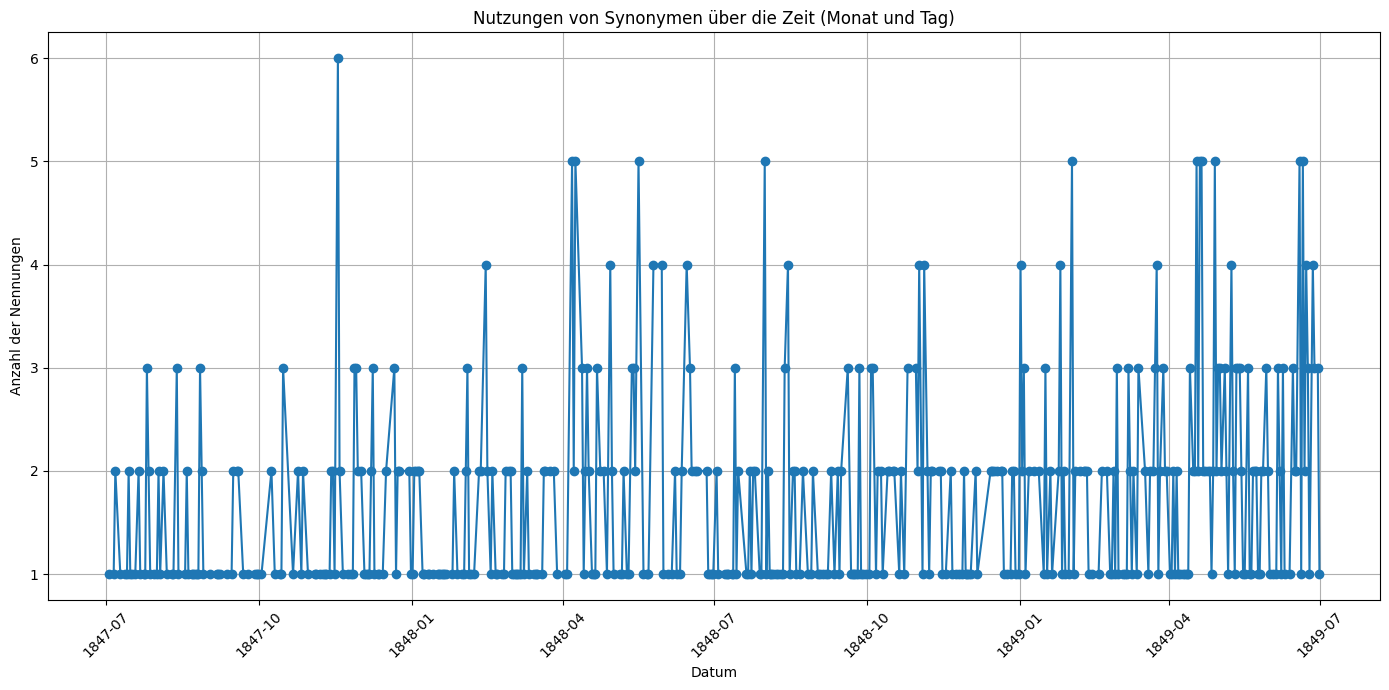

In [ ]:
df_synonyme = df_synonyme.copy()  # Create an explicit copy to avoid SettingWithCopyWarning
df_synonyme['publication_date'] = pd.to_datetime(df_synonyme['publication_date'])

# Group by full publication date for a more granular timeline
date_counts = df_synonyme['publication_date'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Nutzungen von Synonymen über die Zeit (Monat und Tag)')
plt.xlabel('Datum')
plt.ylabel('Anzahl der Nennungen')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Diese Tabelle Zeigt die nutzung von Lügenpresse-Synonymen über den publikationszeitraum der Deutschen Zeitung hinweg. Jeder Punkt repräsentiert ein Datum an dem die Zeitung veröffentlicht wird. Es ist klar zu erkennen dass in vielen (den meisten) Ausgaben Synonyme nur auf einer Seite benutzt wurden. Während in nur einer Ausgabe auf 6 Seiten Synonyme benutzt wurden. Die Nutzung von Lügenpresse Synonymen varierierte stark. Tendenzen zu erkennen ist schwierig, wenn überhaupt einen leichten Anstieg in der ersten Hälfte von 1848.

/tmp/ipykernel_163/3480480563.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_synonyme['year_month'] = df_synonyme['publication_date'].dt.to_period('M')


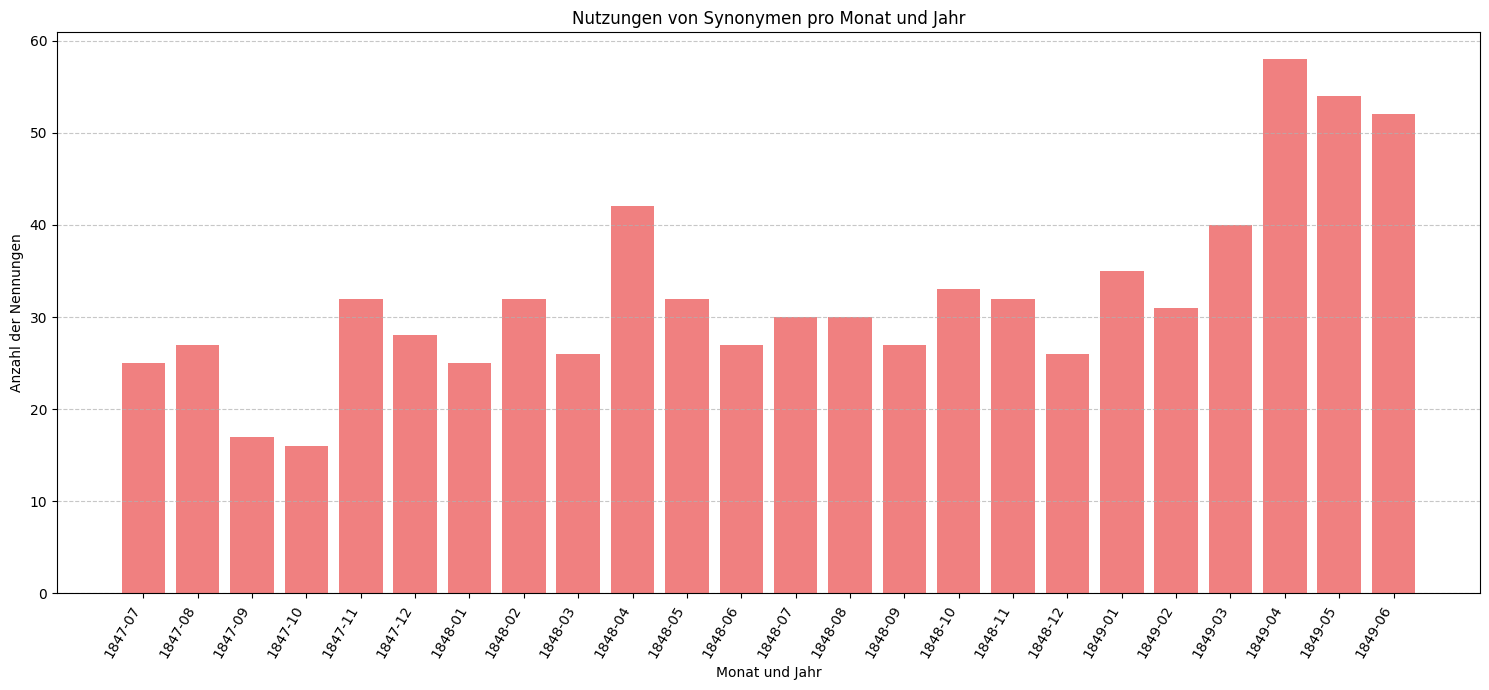

In [ ]:
# Create a 'year_month' column for more specific grouping
df_synonyme['year_month'] = df_synonyme['publication_date'].dt.to_period('M')

# Count occurrences per year-month combination
year_month_counts = df_synonyme['year_month'].value_counts().sort_index()

# Convert Period objects to strings for better plotting labels
year_month_labels = year_month_counts.index.astype(str)

plt.figure(figsize=(15, 7))
plt.bar(year_month_labels, year_month_counts.values, color='lightcoral')
plt.title('Nutzungen von Synonymen pro Monat und Jahr')
plt.xlabel('Monat und Jahr')
plt.ylabel('Anzahl der Nennungen')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Dieser Plot bietet eine Übersicht der Synonymnutzung über die Monate der Jahre 1847 bis 1849. Man kann nun präzise erkennen, in welchen spezifischen Monaten und Jahren die Nutzung am stärksten war, was genaueren Rückschlüsse auf kurzfristige Trends oder Ereignisse ermöglicht.

Ich habe allerdings im Kopf dass die Deutsche Zeitung im Januar 1847 zum ersten Mal erschienen ist. Es wäre also vielleicht hilfreich zu vergleichen wie sich die Publikationen in unseren zwei Datensätzten unterscheiden. Z.b. wann ist die erste Ausgabe der Deutschen Zeitung erschienen vs. wann die erste die ein Synonym benutzt. Wie viele Ausgaben sind im September 1847 erschienen vs wie viele davon haben eines der Synonyme benutzt, sind die 20 in dem Graphen tatsächlich 20 Ausgaben auf denen ein Synonym benutzt wurde oder nur 20 Seiten verteilt auf 3 Ausgaben die sich sehr intensiv mit dem Thema beschäftigt haben?

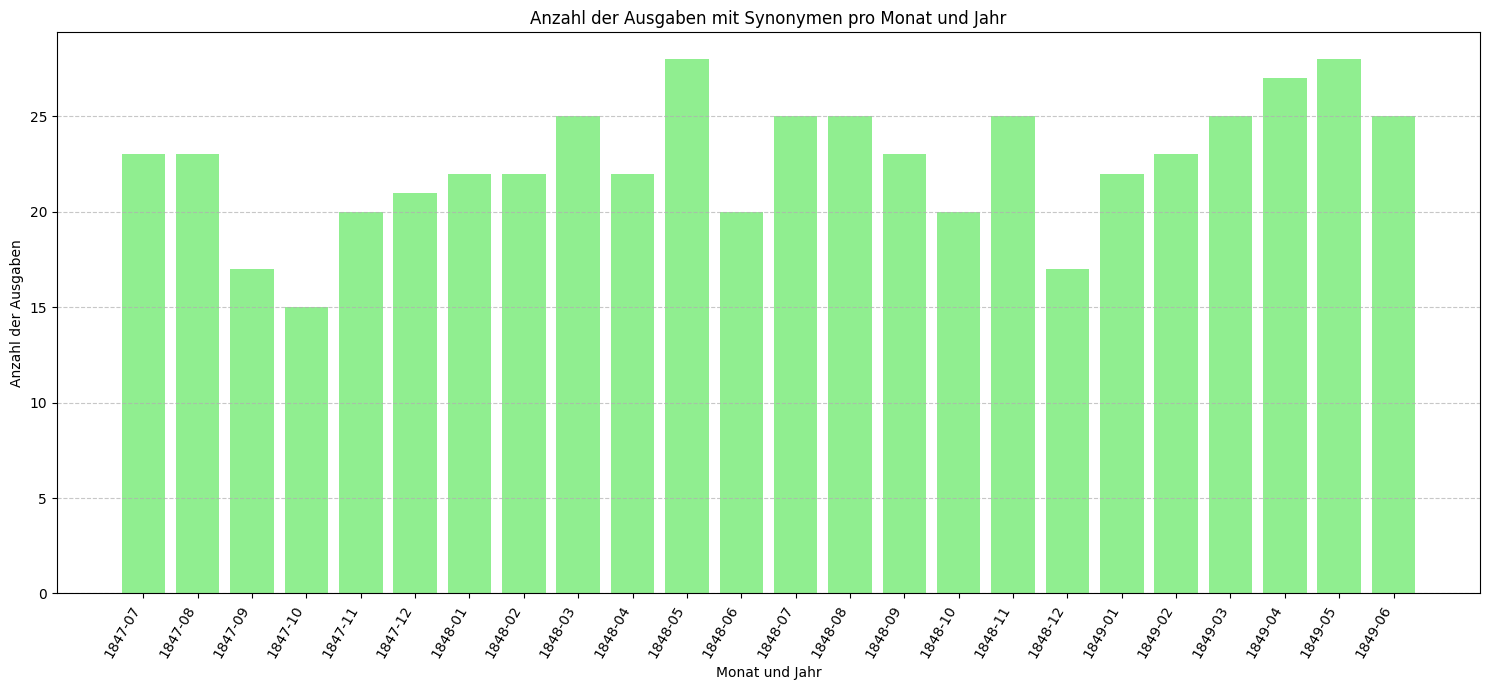

In [ ]:
# Ensure 'publication_date' is in datetime format
df_synonyme_copy = df_synonyme.copy() # Work on a copy to avoid SettingWithCopyWarning
df_synonyme_copy['publication_date'] = pd.to_datetime(df_synonyme_copy['publication_date'])

# Get unique publication dates (representing unique issues)
unique_issues = df_synonyme_copy['publication_date'].dt.date.unique()
unique_issues_df = pd.DataFrame({'publication_date': unique_issues})

# Create a 'year_month' column for these unique issues
unique_issues_df['year_month'] = pd.to_datetime(unique_issues_df['publication_date']).dt.to_period('M')

# Count unique issues per year-month combination
unique_issues_year_month_counts = unique_issues_df['year_month'].value_counts().sort_index()

# Convert Period objects to strings for better plotting labels
year_month_labels_issues = unique_issues_year_month_counts.index.astype(str)

plt.figure(figsize=(15, 7))
plt.bar(year_month_labels_issues, unique_issues_year_month_counts.values, color='lightgreen')
plt.title('Anzahl der Ausgaben mit Synonymen pro Monat und Jahr')
plt.xlabel('Monat und Jahr')
plt.ylabel('Anzahl der Ausgaben')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Zum Vergleich wäre es interessant zu schauen wie viele Ausgaben denn überhaupt veröffentlicht wurden, dann können wir vergleichen in wie viel prozent dieser Ausgaben ein Synonym vorkam.

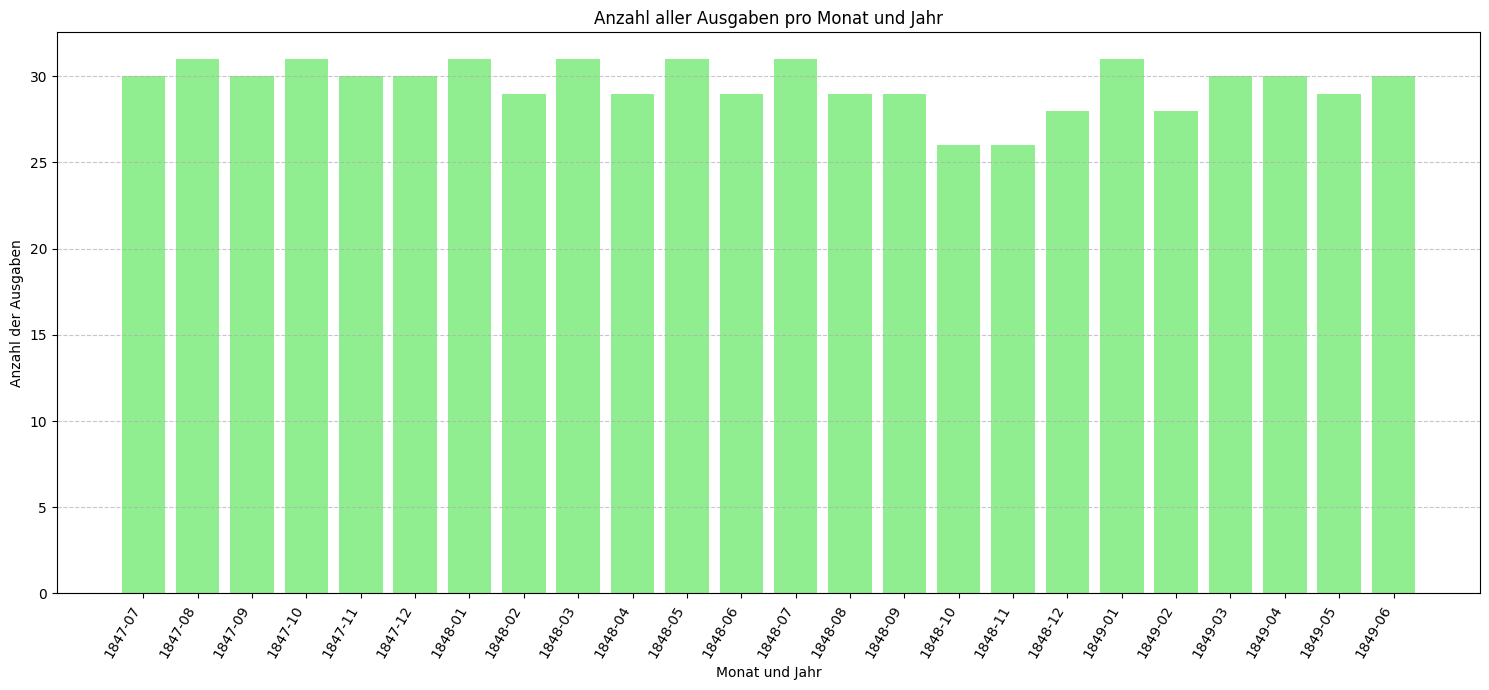

In [ ]:
# Der code von oben sollte leicht zu ändern sein
# Ensure 'publication_date' is in datetime format
df_copy = df.copy()
df_copy['publication_date'] = pd.to_datetime(df_copy['publication_date'])

# Get unique publication dates (representing unique issues)
unique_issues = df_copy['publication_date'].dt.date.unique()
unique_issues_df = pd.DataFrame({'publication_date': unique_issues})

# Create a 'year_month' column for these unique issues
unique_issues_df['year_month'] = pd.to_datetime(unique_issues_df['publication_date']).dt.to_period('M')

# Count unique issues per year-month combination
unique_issues_year_month_counts = unique_issues_df['year_month'].value_counts().sort_index()

# Convert Period objects to strings for better plotting labels
year_month_labels_issues = unique_issues_year_month_counts.index.astype(str)

plt.figure(figsize=(15, 7))
plt.bar(year_month_labels_issues, unique_issues_year_month_counts.values, color='lightgreen')
plt.title('Anzahl aller Ausgaben pro Monat und Jahr')
plt.xlabel('Monat und Jahr')
plt.ylabel('Anzahl der Ausgaben')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

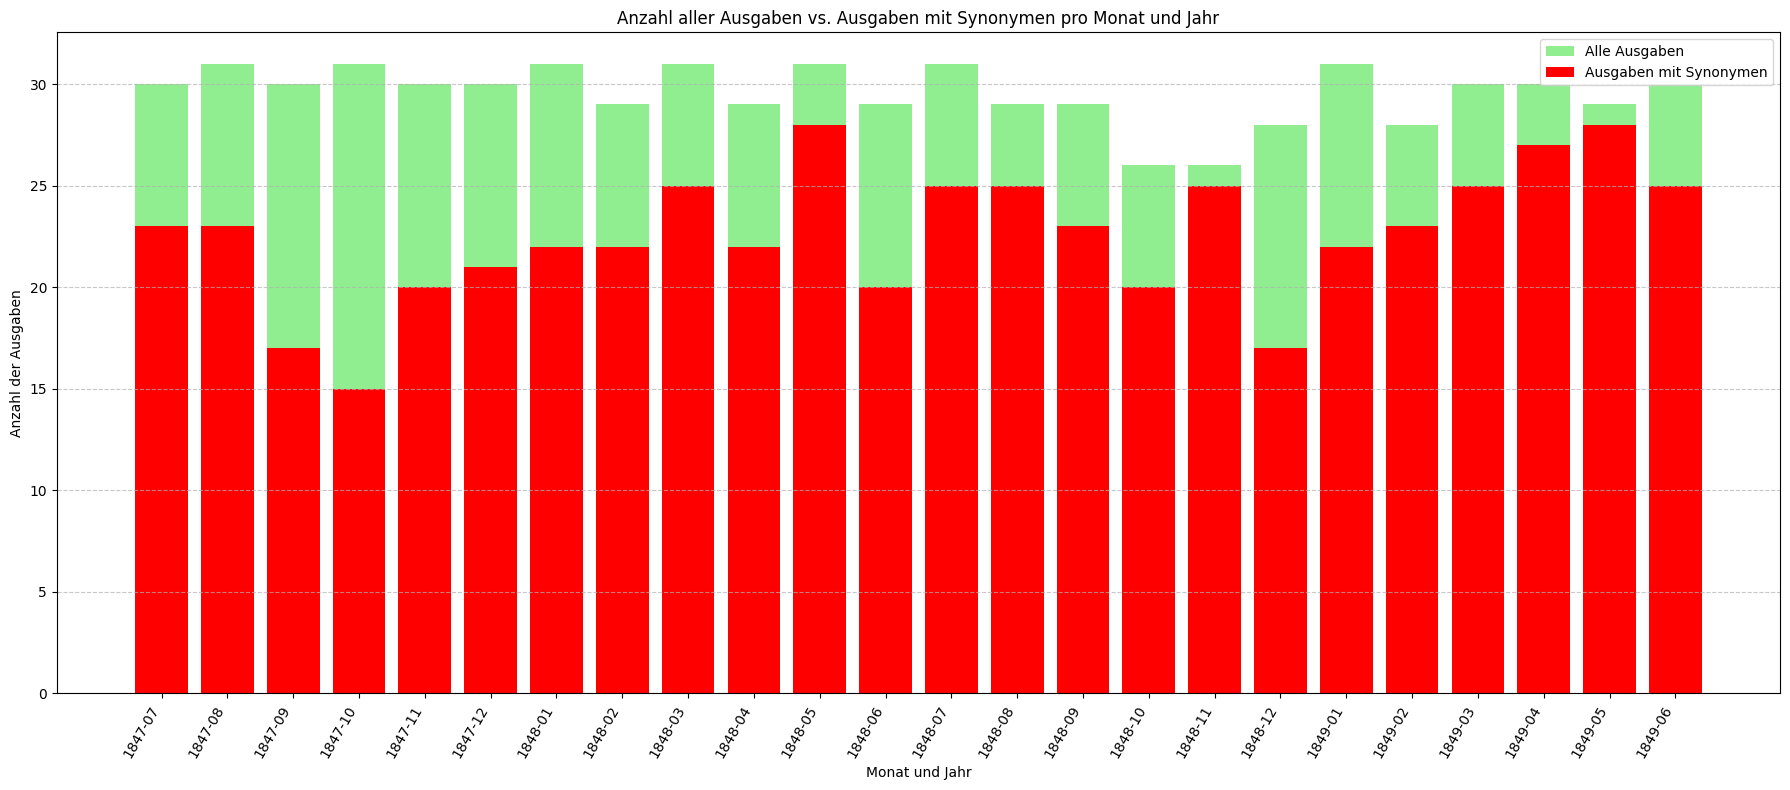

In [ ]:
# --- Data preparation for combined plot ---

# Ensure 'publication_date' is in datetime format for the full dataset (df)
df_full_copy = df.copy()
df_full_copy['publication_date'] = pd.to_datetime(df_full_copy['publication_date'])

# Get unique publication dates for the full dataset
unique_full_issues = df_full_copy['publication_date'].dt.date.unique()
unique_full_issues_df = pd.DataFrame({'publication_date': unique_full_issues})
unique_full_issues_df['year_month'] = pd.to_datetime(unique_full_issues_df['publication_date']).dt.to_period('M')
unique_full_counts = unique_full_issues_df['year_month'].value_counts().sort_index()

# Ensure 'publication_date' is in datetime format for the synonym dataset (df_synonyme)
df_synonyme_for_plot = df_synonyme.copy()
df_synonyme_for_plot['publication_date'] = pd.to_datetime(df_synonyme_for_plot['publication_date'])

# Get unique publication dates for the synonym dataset
unique_synonym_issues = df_synonyme_for_plot['publication_date'].dt.date.unique()
unique_synonym_issues_df = pd.DataFrame({'publication_date': unique_synonym_issues})
unique_synonym_issues_df['year_month'] = pd.to_datetime(unique_synonym_issues_df['publication_date']).dt.to_period('M')
unique_synonym_counts = unique_synonym_issues_df['year_month'].value_counts().sort_index()

# Align indices for plotting (important if one dataset has months the other doesn't)
all_year_months = unique_full_counts.index.union(unique_synonym_counts.index)
full_aligned_counts = unique_full_counts.reindex(all_year_months, fill_value=0)
synonym_aligned_counts = unique_synonym_counts.reindex(all_year_months, fill_value=0)

# Convert Period objects to strings for plotting labels
year_month_labels = all_year_months.astype(str)

# --- Plotting ---
plt.figure(figsize=(18, 8))

# Plot all publications as background (green)
plt.bar(year_month_labels, full_aligned_counts.values, color='lightgreen', label='Alle Ausgaben')

# Plot publications with synonyms on top (red)
plt.bar(year_month_labels, synonym_aligned_counts.values, color='red', label='Ausgaben mit Synonymen')

plt.title('Anzahl aller Ausgaben vs. Ausgaben mit Synonymen pro Monat und Jahr')
plt.xlabel('Monat und Jahr')
plt.ylabel('Anzahl der Ausgaben')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Die hellgrünen Balken stellen die Gesamtzahl der veröffentlichten Ausgaben pro Monat und Jahr dar. Die roten Balken, die darüber liegen, zeigen die Anzahl der Ausgaben im selben Zeitraum, die mindestens eines der von Ihnen definierten Synonyme enthalten. Dies ermöglicht einen direkten Vergleich, wie häufig Synonyme in Relation zur Gesamtproduktion der Zeitung in den jeweiligen Monaten verwendet wurden. Man kann nun visuell erkennen, in welchen Monaten und Jahren der Anteil der synonymhaltigen Ausgaben besonders hoch oder niedrig war.

In [ ]:
# Create a DataFrame from the aligned counts
table_data = pd.DataFrame({
    'Veröffentlichungen insgesamt': full_aligned_counts,
    'Veröffentlichungen Synonyme': synonym_aligned_counts
})

# Calculate the percentage of publications with synonyms
table_data['% Synonyme'] = (table_data['Veröffentlichungen Synonyme'] / table_data['Veröffentlichungen insgesamt'] * 100).round(2)

# Display the table with color-coded '% Synonyme' column
display(table_data.style.background_gradient(subset=['% Synonyme'], cmap='Blues'))

,Veröffentlichungen insgesamt,Veröffentlichungen Synonyme,% Synonyme
year_month,,,
1847-07,30,23,76.670000
1847-08,31,23,74.190000
1847-09,30,17,56.670000
1847-10,31,15,48.390000
1847-11,30,20,66.670000
1847-12,30,21,70.000000
1848-01,31,22,70.970000
1848-02,29,22,75.860000
1848-03,31,25,80.650000
